# GraphFrame

## 1. Setup

In [1]:
#Checking the installed Java version
!java -version

openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-124.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-124.04, mixed mode, sharing)


In [2]:
!pip install pyspark

In [3]:
# Install Java 17
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless

Hit:1 https://download.docker.com/linux/ubuntu noble InRelease
Hit:2 https://cli.github.com/packages stable InRelease                         
Hit:3 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-security InRelease 
Hit:7 https://packages.cloud.google.com/apt cloud-sdk InRelease                
Hit:8 http://deb.wakemeops.com/wakemeops stable InRelease                      
Hit:9 https://archive.ubuntu.com/ubuntu noble InRelease             
Get:10 https://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:11 https://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:12 https://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Fetched 378 kB in 1s (323 kB/s)   
Reading package lists... Done
Reading package l

In [4]:
# Set JAVA_HOME to Java 17
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
        .master("local[*]")\
        .appName("GraphFrames")\
        .config("spark.jars.packages", "graphframes:graphframes:0.8.2-spark3.1-s_2.12") \
        .getOrCreate()

:: loading settings :: url = jar:file:/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/zeus/.ivy2/cache
The jars for the packages stored in: /home/zeus/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-edb688a7-f758-4213-962c-06cd65e3d693;1.0
	confs: [default]
	found graphframes#graphframes;0.8.2-spark3.1-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 108ms :: artifacts dl 5ms
	:: modules in use:
	graphframes#graphframes;0.8.2-spark3.1-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	-------------------------------------

In [6]:
#Read saved parquet, for this section only 2018-09 is used
df = spark.read.option("mergeSchema", "true").parquet("cleaned_flights_parquet/Year=2018/Month=9/part-00057-49ae4c91-dc17-4fa7-ada1-a7d61e408c4e.c000.snappy.parquet","cleaned_flights_parquet/Year=2018/Month=9/part-00058-49ae4c91-dc17-4fa7-ada1-a7d61e408c4e.c000.snappy.parquet")
df.show()
df.count()

25/12/10 09:28:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+---------+
|   FL_DATE|OP_CARRIER|OP_CARRIER_FL_NUM|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|DIVERTED|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|DISTANCE|CARRIER_DELAY|WEATHER_DELAY|NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|IsDelayed|
+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+---------+
|2018-09-03|        9E|             3280|   DFW| CVG|        

559235

In [7]:
from pyspark.sql.functions import col, count, when

In [8]:
#df.printSchema()

root
 |-- FL_DATE: date (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- CRS_DEP_TIME: integer (nullable = true)
 |-- DEP_TIME: float (nullable = true)
 |-- DEP_DELAY: float (nullable = true)
 |-- TAXI_OUT: float (nullable = true)
 |-- WHEELS_OFF: float (nullable = true)
 |-- WHEELS_ON: float (nullable = true)
 |-- TAXI_IN: float (nullable = true)
 |-- CRS_ARR_TIME: integer (nullable = true)
 |-- ARR_TIME: float (nullable = true)
 |-- ARR_DELAY: float (nullable = true)
 |-- CANCELLED: float (nullable = true)
 |-- DIVERTED: float (nullable = true)
 |-- CRS_ELAPSED_TIME: float (nullable = true)
 |-- ACTUAL_ELAPSED_TIME: float (nullable = true)
 |-- AIR_TIME: float (nullable = true)
 |-- DISTANCE: float (nullable = true)
 |-- CARRIER_DELAY: float (nullable = true)
 |-- WEATHER_DELAY: float (nullable = true)
 |-- NAS_DELAY: float (nullable = true)
 |--

In [9]:
%pip install graphframes-py==0.10.0

In [10]:
from graphframes import *
#import data types - All data types of Spark SQL are located in the package of pyspark.sql.types
from pyspark.sql.types import *
#row can be used to create a row object by using named arguments
from pyspark.sql import Row
from pyspark.sql.functions import col

## 2. Graphframe

In [11]:
#Creating Edges
edges_df = df.select(col("ORIGIN").alias('src'), col("DEST").alias('dst'), col("IsDelayed"), col("AIR_TIME"), col("DISTANCE"))
edges_df.show(5)

+---+---+---------+--------+--------+
|src|dst|IsDelayed|AIR_TIME|DISTANCE|
+---+---+---------+--------+--------+
|DFW|CVG|        0|   108.0|   812.0|
|DFW|CVG|        0|   102.0|   812.0|
|DFW|CVG|        0|   104.0|   812.0|
|DFW|CVG|        0|   106.0|   812.0|
|DFW|CVG|        0|   108.0|   812.0|
+---+---+---------+--------+--------+
only showing top 5 rows



In [12]:
#Creating Vertices
vertices_df = df.select(col("ORIGIN").alias('id')).distinct()
vertices_df.show(5)


+---+
| id|
+---+
|PSE|
|MSY|
|GEG|
|BUR|
|SNA|
+---+
only showing top 5 rows



In [13]:
#Creating the graph
flights_graph = GraphFrame(vertices_df, edges_df)

flights_graph.vertices.show()
print(flights_graph.vertices.count())

flights_graph.edges.show()
print(flights_graph.edges.count())

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/sql/dataframe.py:168: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


+---+
| id|
+---+
|PSE|
|MSY|
|GEG|
|BUR|
|SNA|
|GRB|
|GRR|
|JLN|
|PSG|
|PVD|
|GSO|
|MYR|
|OAK|
|MSN|
|FSM|
|FAR|
|SCC|
|DCA|
|GTR|
|CID|
+---+
only showing top 20 rows

346
+---+---+---------+--------+--------+
|src|dst|IsDelayed|AIR_TIME|DISTANCE|
+---+---+---------+--------+--------+
|DFW|CVG|        0|   108.0|   812.0|
|DFW|CVG|        0|   102.0|   812.0|
|DFW|CVG|        0|   104.0|   812.0|
|DFW|CVG|        0|   106.0|   812.0|
|DFW|CVG|        0|   108.0|   812.0|
|DFW|CVG|        0|   109.0|   812.0|
|DFW|CVG|        0|   110.0|   812.0|
|DFW|CVG|        1|   102.0|   812.0|
|DFW|CVG|        1|   110.0|   812.0|
|DFW|CVG|        0|   101.0|   812.0|
|DFW|CVG|        0|   111.0|   812.0|
|DFW|CVG|        0|    98.0|   812.0|
|DFW|CVG|        0|   107.0|   812.0|
|DFW|CVG|        0|   105.0|   812.0|
|LGA|PWM|        0|    45.0|   269.0|
|LGA|PWM|        0|    44.0|   269.0|
|LGA|PWM|        0|    44.0|   269.0|
|LGA|PWM|        0|    45.0|   269.0|
|LGA|PWM|        0|    47.0|

In [14]:
#Degrees
flights_graph.inDegrees.orderBy("inDegree", ascending=False).show()
flights_graph.outDegrees.orderBy("outDegree", ascending=False).show()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


+---+--------+
| id|inDegree|
+---+--------+
|ATL|   30765|
|ORD|   27281|
|DFW|   22016|
|CLT|   18736|
|DEN|   18722|
|LAX|   17151|
|IAH|   14044|
|SFO|   13821|
|LGA|   13310|
|MSP|   12903|
|LAS|   12523|
|PHX|   12355|
|DTW|   12318|
|BOS|   11921|
|SEA|   11606|
|EWR|   11337|
|DCA|   10597|
|JFK|   10594|
|MCO|    9540|
|PHL|    9259|
+---+--------+
only showing top 20 rows

+---+---------+
| id|outDegree|
+---+---------+
|ATL|    30676|
|ORD|    27297|
|DFW|    22044|
|CLT|    18797|
|DEN|    18542|
|LAX|    17134|
|IAH|    14065|
|SFO|    13852|
|LGA|    13318|
|MSP|    12915|
|PHX|    12521|
|LAS|    12497|
|DTW|    12297|
|BOS|    11896|
|SEA|    11629|
|EWR|    11328|
|JFK|    10600|
|DCA|    10539|
|MCO|     9559|
|PHL|     9305|
+---+---------+
only showing top 20 rows



In [15]:
#Page Ranks for all flights
pageRanks = flights_graph.pageRank(resetProbability=0.15, maxIter = 5)
pageRanks.vertices.orderBy("pagerank", ascending=False).show()
pageRanks.vertices.orderBy("pagerank", ascending=True).show()

+---+------------------+
| id|          pagerank|
+---+------------------+
|ATL| 17.30364372469518|
|ORD| 16.20126847138928|
|DFW|14.380620304620544|
|DEN|12.106789430129078|
|CLT|10.755228788847337|
|MSP| 8.529002548904991|
|LAX|  8.27564897470479|
|IAH| 7.746113314513614|
|DTW| 7.433397814780173|
|SFO| 7.107658195594365|
|SEA| 6.764057287092888|
|PHX| 6.469688023317703|
|LAS|6.3797674081305695|
|LGA| 6.320505254157433|
|SLC|  6.15820927385515|
|EWR| 5.424649672299708|
|BOS| 5.385662288683547|
|JFK|5.3396900046967986|
|DCA|    5.083941499838|
|MCO| 4.642648214521249|
+---+------------------+
only showing top 20 rows

+---+-------------------+
| id|           pagerank|
+---+-------------------+
|HYA|0.15163991748109756|
|PPG| 0.1542295790063413|
|HDN| 0.1548016990058201|
|SMX|0.15553770589243784|
|BKG|0.15906987589988428|
|STC|0.16129824857704084|
|ADK| 0.1624145267982329|
|HGR| 0.1649741182830634|
|OWB| 0.1649741182830634|
|OTH|0.16637531644462988|
|MVY| 0.1673882055136128|
|OGD|0.168

In [16]:
#Delayed Flights
flights_graph.filterEdges("IsDelayed = 1").edges.show()
flights_graph.filterEdges("IsDelayed= 1").edges.count()

+---+---+---------+--------+--------+
|src|dst|IsDelayed|AIR_TIME|DISTANCE|
+---+---+---------+--------+--------+
|DFW|CVG|        1|   102.0|   812.0|
|DFW|CVG|        1|   110.0|   812.0|
|LGA|PWM|        1|    44.0|   269.0|
|LGA|PWM|        1|    43.0|   269.0|
|LGA|PWM|        1|    44.0|   269.0|
|LGA|PWM|        1|    44.0|   269.0|
|VLD|ATL|        1|    48.0|   208.0|
|JFK|DCA|        1|    54.0|   213.0|
|RDU|LGA|        1|    68.0|   431.0|
|ATL|TYS|        1|    30.0|   152.0|
|ATL|TYS|        1|    32.0|   152.0|
|ATL|TYS|        1|    28.0|   152.0|
|ATL|TYS|        1|    34.0|   152.0|
|ATL|TYS|        1|    27.0|   152.0|
|ATL|TYS|        1|    34.0|   152.0|
|JFK|DTW|        1|    87.0|   509.0|
|CHS|LGA|        1|    90.0|   641.0|
|CHS|LGA|        1|   115.0|   641.0|
|DTW|PVD|        1|    90.0|   615.0|
|DTW|PVD|        1|    76.0|   615.0|
+---+---+---------+--------+--------+
only showing top 20 rows



88968

In [17]:
#Page ranks for delayed flights
pageRanks = flights_graph.filterEdges("IsDelayed = 1").pageRank(resetProbability=0.15, maxIter = 5)
pageRanks.vertices.orderBy("pagerank", ascending=False).show()
pageRanks.vertices.orderBy("pagerank", ascending=True).show()

25/12/10 09:28:32 WARN CacheManager: Asked to cache already cached data.


+---+------------------+
| id|          pagerank|
+---+------------------+
|ORD|17.538585742142992|
|DFW| 17.37129804038936|
|ATL|13.599116611968604|
|DEN|10.187700563771545|
|IAH| 9.807439892612894|
|CLT|  9.74107456849031|
|EWR| 9.513329603118091|
|LGA| 8.712804152304072|
|SEA| 8.681309635552108|
|SFO| 8.147124968350877|
|BOS| 8.019204461880124|
|LAX| 7.174085780625479|
|JFK|  6.81881350047182|
|MSP| 6.795429765669429|
|PHX| 6.092514690884408|
|LAS| 5.858319480599295|
|DTW| 5.774313862133153|
|PHL| 5.673870284283272|
|DCA| 5.495979315794886|
|MCO| 4.655049174842148|
+---+------------------+
only showing top 20 rows

+---+-------------------+
| id|           pagerank|
+---+-------------------+
|HDN|0.15189040983667842|
|HGR|0.15189040983667842|
|CDC|0.15189040983667842|
|HYA|0.15189040983667842|
|OWB|0.15189040983667842|
|MVY|0.15470750239556905|
|CNY|0.15496100102429022|
|GCC|0.15496100102429022|
|TWF|0.15604573343349326|
|CPR|0.15604573343349326|
|EKO|0.15604573343349326|
|LBF|0.158

In [18]:
#Percent of delayed flights per city (outDegrees)
frame = flights_graph.outDegrees
frame2 = flights_graph.filterEdges("IsDelayed = 1").outDegrees
flights_cancel_proportion_out_results = frame.alias("f").join(frame2.alias("f2"), on="id", how="inner").withColumn("Proportion", col("f2.outDegree") / col("f.outDegree"))
flights_cancel_proportion_out_results.orderBy("Proportion", ascending = False).show()

+---+---------+---------+-------------------+
| id|outDegree|outDegree|         Proportion|
+---+---------+---------+-------------------+
|ADK|        9|        5| 0.5555555555555556|
|BKG|       17|        9| 0.5294117647058824|
|OGD|        8|        4|                0.5|
|ORH|       89|       32| 0.3595505617977528|
|TTN|      226|       79| 0.3495575221238938|
|SMX|       13|        4| 0.3076923076923077|
|JLN|       58|       17|0.29310344827586204|
|LWB|       63|       18| 0.2857142857142857|
|PRC|       51|       14|0.27450980392156865|
|SCK|       63|       17| 0.2698412698412698|
|SWF|      144|       36|               0.25|
|PPG|        8|        2|               0.25|
|OWB|        8|        2|               0.25|
|FSM|      167|       41|0.24550898203592814|
|DFW|    22044|     5342| 0.2423335147886046|
|HTS|       62|       15|0.24193548387096775|
|LAW|      104|       25| 0.2403846153846154|
|SUX|      109|       26|0.23853211009174313|
|MFE|      370|       88|0.2378378

As we can see, ADK, BKG and OGD have over 50% of delayed flights

In [19]:
#Percent of delayed flights per city (inDegrees)
frame = flights_graph.inDegrees
frame2 = flights_graph.filterEdges("IsDelayed = 1").inDegrees
flights_cancel_proportion_in_results = frame.alias("f").join(frame2.alias("f2"), on="id", how="inner").withColumn("Proportion", col("f2.inDegree") / col("f.inDegree"))
flights_cancel_proportion_in_results.orderBy("Proportion", ascending = False).show()

+---+--------+--------+-------------------+
| id|inDegree|inDegree|         Proportion|
+---+--------+--------+-------------------+
|BKG|      17|       9| 0.5294117647058824|
|OGD|       8|       4|                0.5|
|PSM|      11|       4|0.36363636363636365|
|TTN|     223|      78|0.34977578475336324|
|ORH|      89|      31|0.34831460674157305|
|PGV|      82|      26| 0.3170731707317073|
|SMX|      13|       4| 0.3076923076923077|
|CMX|      54|      16| 0.2962962962962963|
|SUX|     109|      32|0.29357798165137616|
|MFE|     373|     108|  0.289544235924933|
|EWR|   11337|    3188| 0.2812031401605363|
|LAW|     103|      28|0.27184466019417475|
|LWB|      64|      17|           0.265625|
|LBB|     459|     118| 0.2570806100217865|
|JLN|      59|      15| 0.2542372881355932|
|CRP|     437|     110| 0.2517162471395881|
|LYH|     135|      33|0.24444444444444444|
|MKG|      54|      13|0.24074074074074073|
|BOS|   11921|    2859|0.23982887341665968|
|COU|     163|      38| 0.233128

In [20]:
#Label Propogation
result = flights_graph.labelPropagation(maxIter=10)

# Display the detected communities
result.select("id", "label").orderBy("label", ascending = False).show()
print(result.count())
result.select("label").groupBy("label").count().sort("count").show()
print(result.select("label").distinct().count())

+---+-----+
| id|label|
+---+-----+
|SPN|  311|
|PSG|  262|
|WRG|  172|
|GUM|  137|
|DVL|   95|
|CDV|   59|
|HRL|   19|
|ATL|   19|
|BMI|   19|
|STL|   19|
|SGF|   19|
|CMI|   19|
|LBB|   19|
|VPS|   19|
|GRI|   19|
|SUX|   19|
|TLH|   19|
|CKB|   19|
|SMF|   19|
|HDN|   19|
+---+-----+
only showing top 20 rows

346
+-----+-----+
|label|count|
+-----+-----+
|  262|    1|
|   95|    1|
|  172|    1|
|  137|    1|
|   59|    1|
|  311|    1|
|   16|    1|
|   19|  339|
+-----+-----+

8


As we can see, most of the cities are connected into a single community

In [21]:
#Exporting the edges data to use for Gephi Lite

#edges_df2 = edges_df.select(col("src").alias('Source'), col("dst").alias('Target'), col("Cancelled"))
#edges_df2.coalesce(1).write.format("csv").option("header", "true").mode("overwrite").save("edges")
#vertices_df.write.csv("Project3")

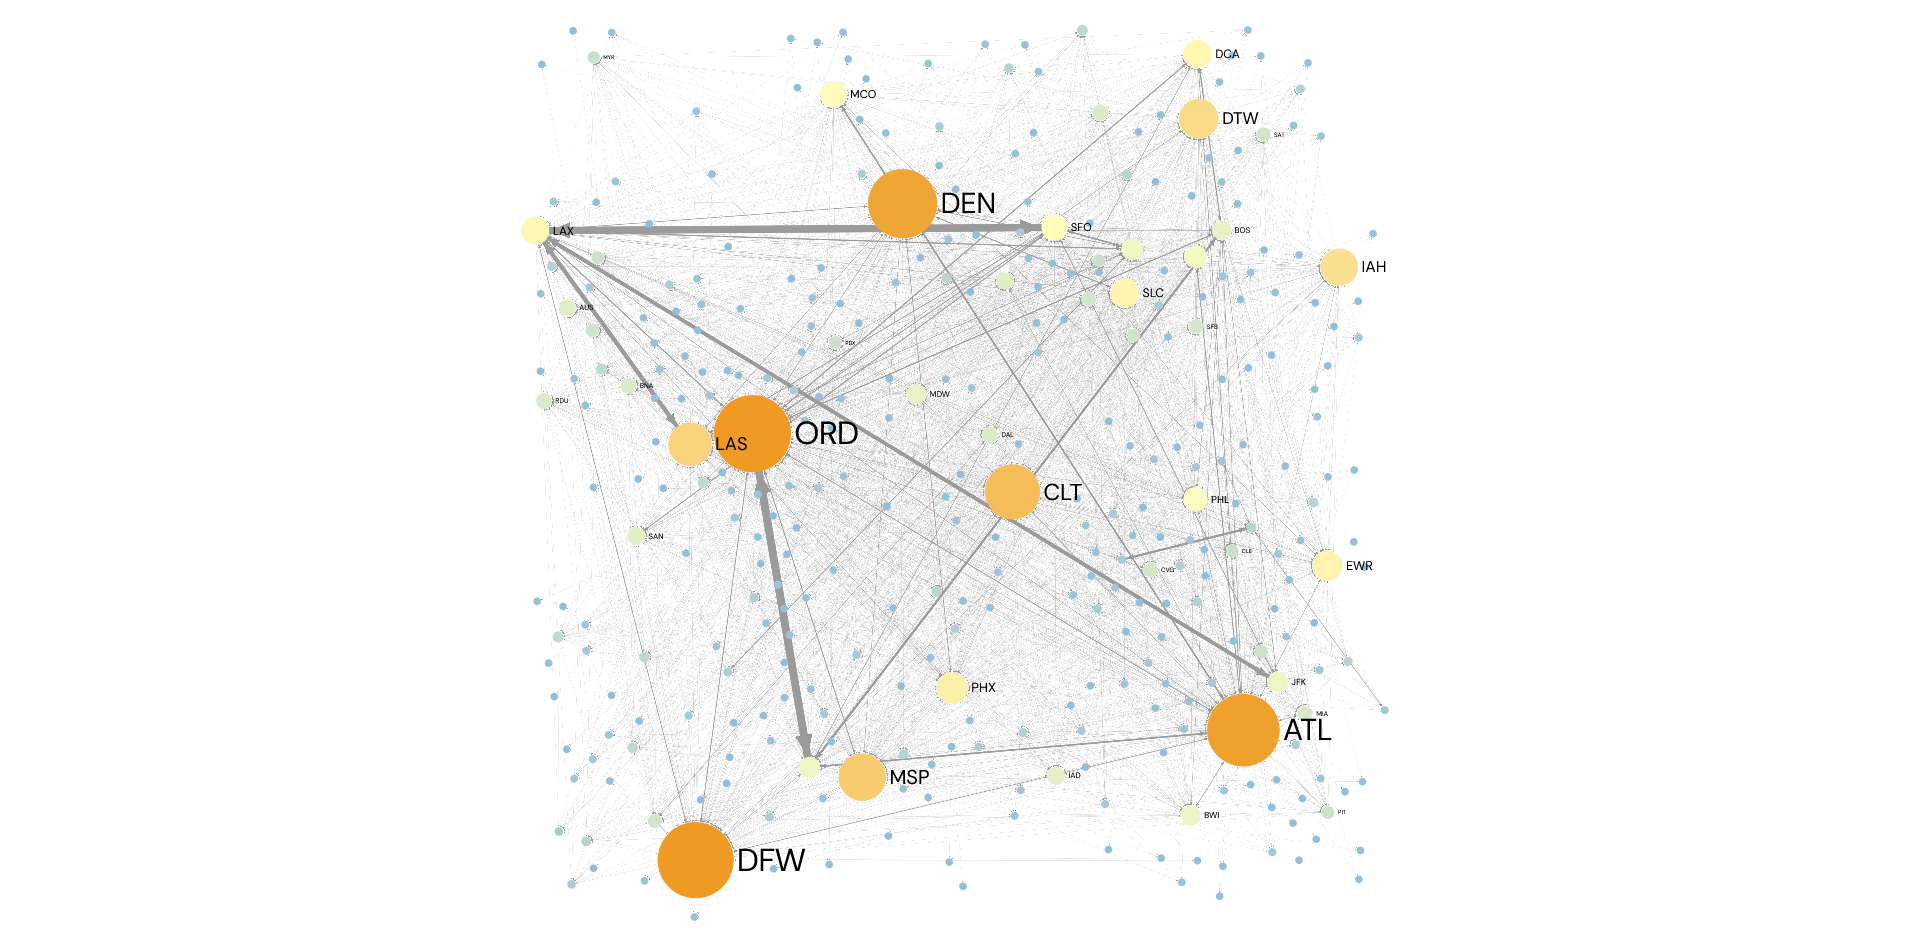

In [22]:
#This visual was made with the help of Gephi Lite (https://lite.gephi.org/v1.0.2/#/)
#The size of edges depends on the amount of connections, and the size and color of nodes depends on overall degree
#The position of nodes is mostly random
from IPython.display import Image
Image("Data/gephi-lite-export(4).png")